Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_1946/1993747222.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, ax=axes[1, 0], palette='Blues_d')


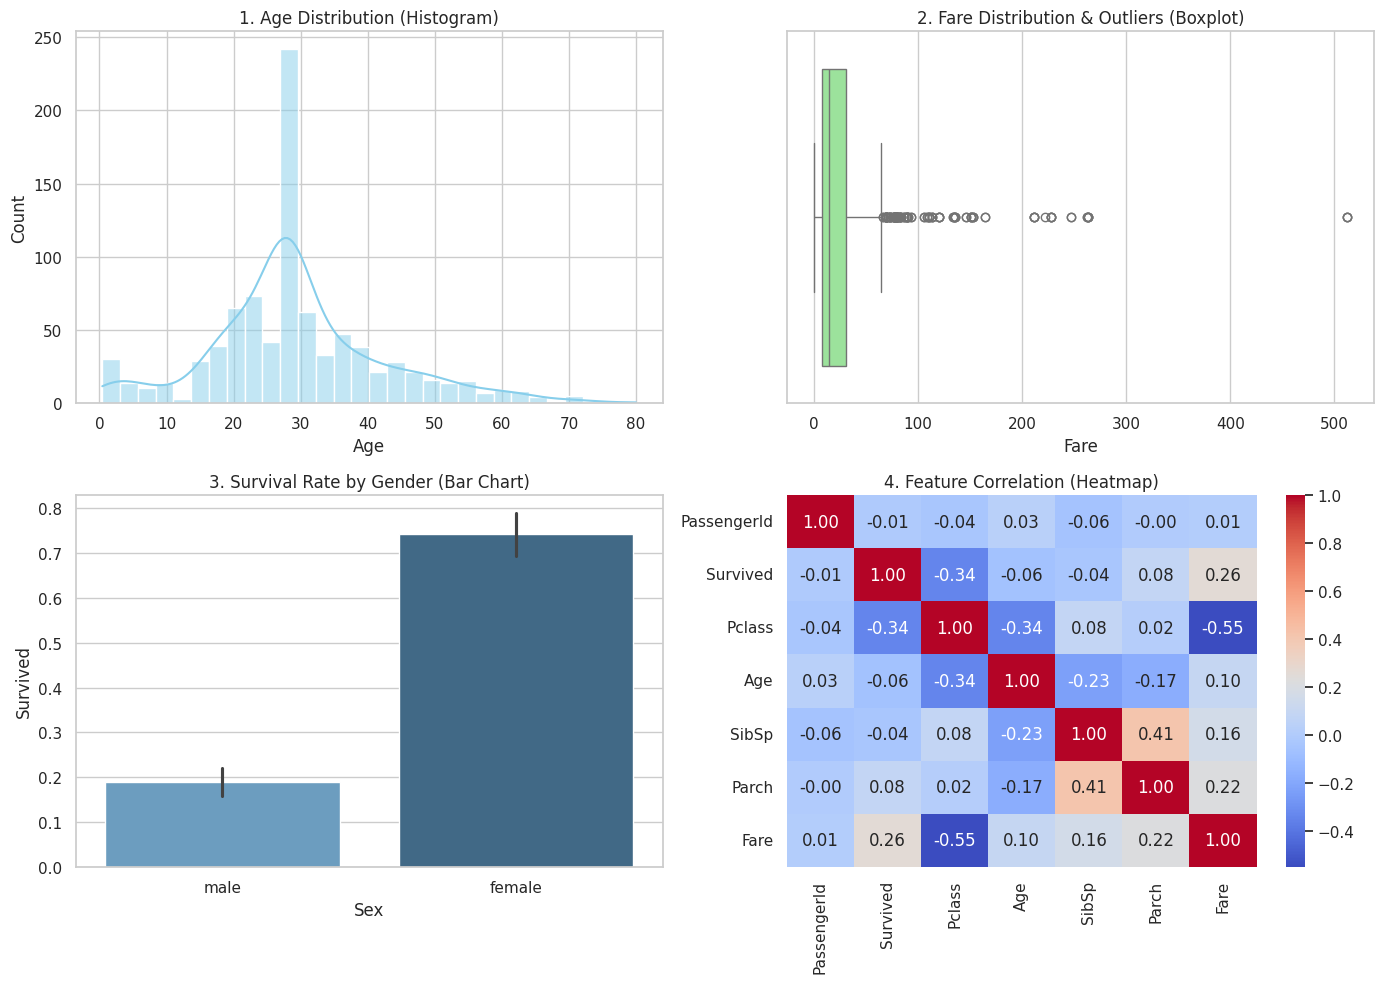

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid")

# 1. Dataset Load Karein
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# ---------------------------------------------------------
# 2. HANDLE MISSING VALUES
# ---------------------------------------------------------

# Age: Fill missing values with median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Embarked: Fill missing values with the most common port (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin: Drop column because >75% of data is missing
df = df.drop(columns=['Cabin'])

print("Missing values after cleaning:")
print(df.isnull().sum())

# ---------------------------------------------------------
# 3. CREATE VISUALIZATIONS (4 Required Charts)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Histogram - Age Distribution
sns.histplot(df['Age'], kde=True, bins=30, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Age Distribution (Histogram)')

# Chart 2: Boxplot - Fare Outliers
sns.boxplot(x=df['Fare'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('2. Fare Distribution & Outliers (Boxplot)')

# Chart 3: Bar Chart - Survival Rate by Gender
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[1, 0], palette='Blues_d')
axes[1, 0].set_title('3. Survival Rate by Gender (Bar Chart)')

# Chart 4: Heatmap - Correlation Matrix
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('4. Feature Correlation (Heatmap)')

plt.tight_layout()
plt.show()